In [2]:
import cobra
from cobra.io import read_sbml_model
from cobra.sampling import sample
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pickle
import os

# Simulations for O'Quinn et al 2026

## Model simulation helper functions

In [3]:
def create_rxn(model, name, cpd_dict, direction="both", limits=None):
    # Create a reaction from a dict with {"CPD1": -1, "CPD2: 1"}
    # Assuming the cpd ids are already in the model
    if direction not in ["forward", "reverse", "both"]:
        raise ValueError("Direction must be either forward, reverse, or both")
    rxn = cobra.Reaction(name)
    if limits is not None:
        if len(limits) != 2:
            raise ValueError("Limits must be of length 2")
        else:
            rxn.lower_bound = limits[0]
            rxn.upper_bound = limits[1]
    elif direction == "both":
        rxn.lower_bound = -1000
        rxn.upper_bound = 1000
    elif direction == "forward":
        rxn.lower_bound = 0
        rxn.upper_bound = 1000
    else:
        rxn.lower_bound = -1000
        rxn.upper_bound = 0
    rxn.add_metabolites({
        getattr(model.metabolites, cpd): val for cpd, val in cpd_dict.items()
    })
    print("Adding the following reaction to model:")
    print(rxn)
    model.add_reactions([rxn])

def plt_contributing_rxns(model, sample, cpd_id, n=10, scale=None):
    rxns = [x.id for x in getattr(model.metabolites, cpd_id).reactions]
    raw_means = sample[rxns].mean(axis=0)
    errors = sample[rxns].std(axis=0)
    for rxn in raw_means.index:
        direction = {cpd.id:val for cpd,val
                     in getattr(model.reactions, rxn).metabolites.items()}[cpd_id]
        raw_means[rxn] = raw_means[rxn]*direction
    topn = pd.concat([raw_means.sort_values(ascending=False).head(n),
                      raw_means.sort_values(ascending=False).tail(n)])
    print(raw_means[raw_means > 0].sum())
    if all(np.isnan(errors)):
        plt.bar(topn.index, topn)
    else:
        plt.bar(topn.index, topn, yerr=errors[topn.index])
    plt.xticks(rotation="vertical")
    if scale is not None:
        plt.yscale(scale)
    plt.tight_layout()
    plt.show()
    
def add_fixed_constraint(model, rxn, value):
    """
    model = cobra formatted model
    rxn = string of reaction id
    value = a single int/float to constrain the reaction to, or a list/tuple like (lb, ub)
    """
    try:
        lower = value[0]
        upper = value[1]
    except (TypeError, IndexError):
        lower = value
        upper = value
    constraint = model.problem.Constraint(
        getattr(model.reactions, rxn).flux_expression,
        lb=lower, ub=upper)
    model.add_cons_vars(constraint)
    return constraint

def plt_hist(*data, rxn=None, bins=20, labels=None, xlabel=None):
    # if rxn is not specified, it will treat the data as arrays
    # otherwise it will treat it as dataframes and subset rxn from them
    if labels is not None and len(data) != len(labels):
        raise ValueError("labels and data must be lists of same length")
    if labels is None:
        labels2 = [None]*len(data)
    else:
        labels2 = labels
    # parse data:
    if rxn is not None:
        arrays = [df[rxn] for df in data]
    else:
        arrays = data
    if type(bins) == int:
        binz = np.linspace(min(np.concatenate(arrays)),
                           max(np.concatenate(arrays)),
                           bins)
    elif len(bins) == 3:
        binz = np.linspace(bins[0], bins[1], bins[2])
    else:
        raise ValueError("Bins must be an integer (number of bins) or a " +
                         "list/tuple of length three; (min, max, nbins)")
    for arr,lab in zip(arrays,labels2):
        plt.hist(arr, bins=binz, label=lab, alpha=0.4, edgecolor="black")
    if labels is not None:
        plt.legend()
    if xlabel is None:
        plt.xlabel(rxn)
    else:
        plt.xlabel(xlabel)
    plt.show()




In [4]:
def get_stoichiometric_contribution(flux_sample, compound_id, model):
    """
    Adjusts the fluxes in your sample to represent the flux of a specific compound
    """
    # Create copy df with all zeros
    new_sample = pd.DataFrame().reindex_like(flux_sample).replace(np.nan, 0)
    for reaction in getattr(model.metabolites, compound_id).reactions:
        new_sample[reaction.id] = flux_sample[reaction.id] * reaction.get_coefficient(compound_id)
    return new_sample

def transform_to_scaled_proportion(row):
    total_flux = np.sum(np.abs(row))/2
    return row/total_flux

In [5]:
def get_phosphorylation_contribution(flux_sample, model):
    """
    Calculates the net phosphorylation state change for each reaction.
    Tracks all nucleotides (ATP, GTP, CTP, UTP, etc.) and free phosphates.
    
    Returns a DataFrame where each value represents the net high-energy 
    phosphate bonds produced (positive) or consumed (negative).
    """
    
    # Define phosphorylation states
    # These are common KEGG/BiGG IDs - adjust for your model
    nucleotide_triphosphates = {
        'C00002': 'atp',    # ATP
        'C00044': 'gtp',    # GTP  
        'C00063': 'ctp',    # CTP
        'C00075': 'utp',    # UTP
        'C00081': 'itp',    # ITP
        'C00131': 'dttp',   # dTTP
        'C00286': 'datp',   # dATP
        'C00459': 'dgtp',   # dGTP
        'C00458': 'dctp',   # dCTP
        'C01345': 'ditp',   # dITP
    }
    
    nucleotide_diphosphates = {
        'C00008': 'adp',    # ADP
        'C00035': 'gdp',    # GDP
        'C00112': 'cdp',    # CDP
        'C00015': 'udp',    # UDP
        'C00104': 'idp',    # IDP
        'C00206': 'dtdp',   # dTDP
        'C00206': 'dadp',   # dADP
        'C00361': 'dgdp',   # dGDP
        'C00705': 'dcdp',   # dCDP
        'C01344': 'didp',   # dIDP
    }
    
    nucleotide_monophosphates = {
        'C00020': 'amp',    # AMP
        'C00144': 'gmp',    # GMP
        'C00055': 'cmp',    # CMP
        'C00105': 'ump',    # UMP
        'C00130': 'imp',    # IMP
        'C00364': 'dtmp',   # dTMP
        'C00413': 'damp',   # dAMP
        'C00362': 'dgmp',   # dGMP
        'C01081': 'dcmp',   # dCMP
        'C06196': 'dimp',   # dIMP
    }
    
    phosphates = {
        'C00009': 'pi',     # Phosphate (Pi)
        'C00013': 'ppi',    # Pyrophosphate (PPi)
    }
    
    # Assign phosphorylation values
    phosphate_values = {}
    for cpd_id in nucleotide_triphosphates.keys():
        phosphate_values[cpd_id] = 2  # 2 high-energy bonds
    for cpd_id in nucleotide_diphosphates.keys():
        phosphate_values[cpd_id] = 1  # 1 high-energy bond
    for cpd_id in nucleotide_monophosphates.keys():
        phosphate_values[cpd_id] = 0  # 0 high-energy bonds
    phosphate_values['C00009'] = 0   # Pi - no high-energy bond
    phosphate_values['C00013'] = 1   # PPi - 1 high-energy bond
    
    # Calculate net phosphorylation for each reaction
    new_sample = pd.DataFrame().reindex_like(flux_sample).replace(np.nan, 0)
    
    for reaction in model.reactions:
        # Calculate net phosphorylation state change
        net_phosphorylation = 0
        
        for metabolite, coefficient in reaction.metabolites.items():
            met_id = metabolite.id
            
            # Check if this metabolite contributes to phosphorylation state
            if met_id in phosphate_values:
                # Positive coefficient = product (increases if value is positive)
                # Negative coefficient = reactant (decreases if value is positive)
                net_phosphorylation += coefficient * phosphate_values[met_id]
        
        # Multiply by flux to get contribution
        new_sample[reaction.id] = flux_sample[reaction.id] * net_phosphorylation
    
    return new_sample

## Loading model and constraining the experimental data

In [6]:
cobra_model = read_sbml_model("../../sbmls/5564dbe3_bdo_cellobiose.sbml")
constraint_data = pd.read_table("./data/2026-03-03_PFU_BDO_carbon_closure.tsv")
outdir = "./output"

'' is not a valid SBML 'SId'.


In [7]:
# Create a model for each strain
# Constrain the data to be mean +/- stderr
models = {strain: cobra_model.copy()
          for strain in constraint_data["strain"].unique()}

for _, row in constraint_data.iterrows():
    # Skip constraining CO2; this is calculated from other products anyways
    if row["id_cobra"] == "TP_CO2":
        continue
    reaction = getattr(models[row["strain"]].reactions, row["id_cobra"])
    reaction.bounds = (row["lb"], row["ub"])

Verifying that the models are feasible under the constraints

In [8]:
for strain, model in models.items():
    try:
        model.optimize()
        cobra.util.assert_optimal(model)
    except (cobra.exceptions.Infeasible, cobra.exceptions.OptimizationError) as e:
        print(f"{strain} failed: {e}")
    else:
        print(f"{strain} passed")

MW698 passed
MW697 passed
MW268 passed
COM1c passed


# Flux sampling

### Only run this if you want to compute new samples

In [9]:
# Random sampling of all the models
samples = {
    strain: sample(model, 5000, processes=4)
    for strain, model in models.items()
}

In [61]:
with open(os.path.join(outdir, "samples_dict.pkl"), 'wb') as f:
    pickle.dump(samples, f)

### Read in the precomputed samples

In [9]:
with open(os.path.join(outdir, "samples_dict.pkl"), 'rb') as f:
    samples = pickle.load(f)

In [10]:
samples_c_adjusted = {
    strain: df.div(-df["EX_C00185_LSQBKT_e_RSQBKT_"], axis=0)
    for strain, df in samples.items()
}

In [11]:
samples_bio_adjusted = {
    strain: df.div(df["Biomass_Pfu"], axis=0)
    for strain, df in samples.items()
}

In [12]:
# Convert from dictionary to pd df
tmp_data = []
for strain, df in samples_c_adjusted.items():
    df2 = df.copy()
    df2["strain"] = strain
    tmp_data.append(df2)

samples_c_adjusted_df = pd.concat(tmp_data)

In [13]:
# Convert from dictionary to pd df
tmp_data = []
for strain, df in samples.items():
    df2 = df.copy()
    df2["strain"] = strain
    tmp_data.append(df2)

samples_df = pd.concat(tmp_data)

# Figure 8: Redox contributions across the model

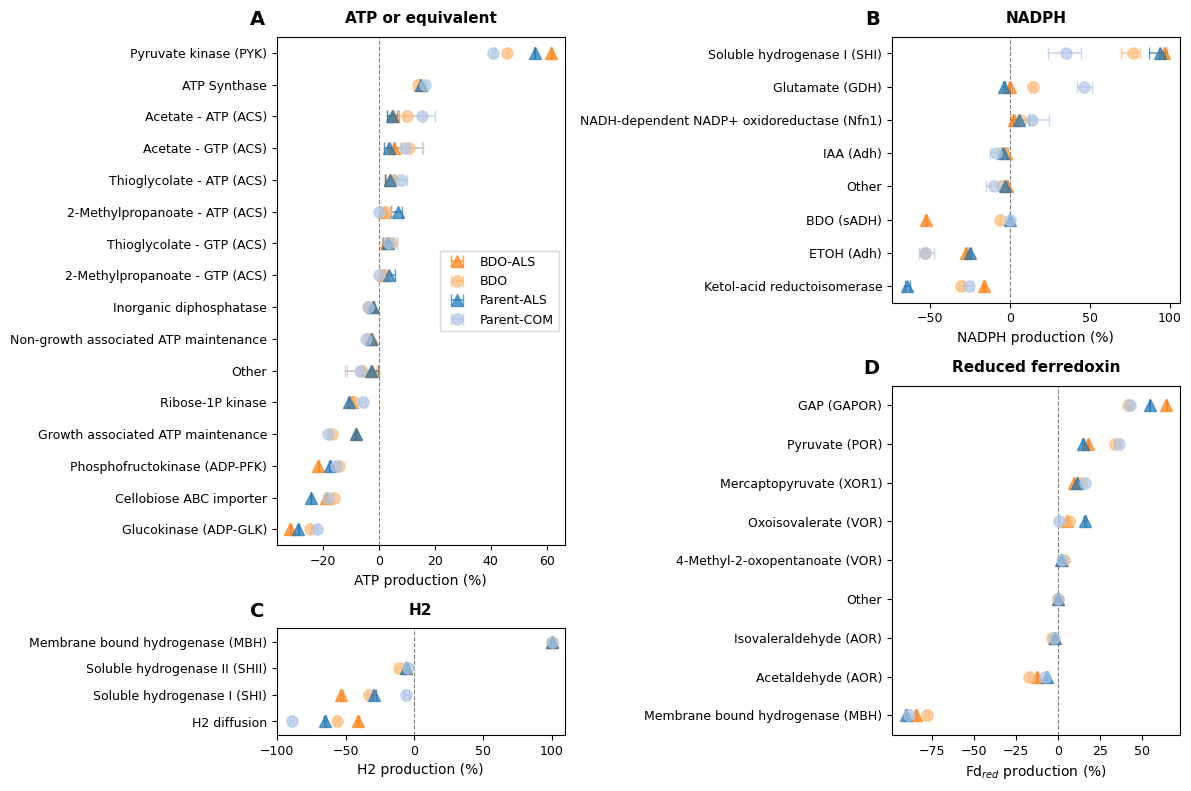

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

# Define configurations for each panel with manual labels
panel_configs = {
    'A': {'target_id': 'Phosphorylation', 'threshold': 3, 'use_percentage': True,
          'title': 'ATP or equivalent', 'xlabel': 'ATP production (%)'},
    'C': {'target_id': 'C00282', 'threshold': 0.0, 'use_percentage': True,
          'title': 'H2', 'xlabel': 'H2 production (%)'},
    'D': {'target_id': 'C00138', 'threshold': 3, 'use_percentage': True,
          'title': 'Reduced ferredoxin', 'xlabel': 'Fd$_{red}$ production (%)'},
    'B': {'target_id': 'C00005', 'threshold': 3, 'use_percentage': True,
          'title': 'NADPH', 'xlabel': 'NADPH production (%)'},
}

# Define layout using subplot_mosaic syntax
layout = [
    ['A', 'B'],
    ['A', 'D'],
    ['C', 'D'],
]
width_ratios = [1, 1]
height_ratios = [0.5, 0.3, 0.2]
figsize = (12, 8)

# Reaction name mapping
reaction_map = {
    "R07181": "Soluble hydrogenase I (SHI)", "TP_H2": "H2 diffusion",
    "R00700": "Soluble hydrogenase II (SHII)", "mbh": "Membrane bound hydrogenase (MBH)",
    "R07159": "GAP (GAPOR)", "R01196": "Pyruvate (POR)",
    "R07160_H": "Oxoisovalerate (VOR)", "xor1": "Mercaptopyruvate (XOR1)",
    "R08566_H": "4-Methyl-2-oxopentanoate (VOR)", "R01197": "α-ketoglutarate (OGOR)",
    "nfn1": "NADH-dependent NADP+ oxidoreductase (Nfn1)", "AOR_Isovaleraldehyde": "Isovaleraldehyde (AOR)",
    "AOR_acetaldehyde": "Acetaldehyde (AOR)",
    "R00248": "Glutamate (GDH)", "Adh_iaa_nadp": "IAA (Adh)",
    "R00746": "ETOH (Adh)", "R04440": "Ketol-acid reductoisomerase",
    "R02946_Tg_sADH": "BDO (sADH)",
    "R00200": "Pyruvate kinase (PYK)", "atps": "ATP Synthase",
    "R00229": "Acetate - ATP (ACS)", "acs3G": "2-Methylpropanoate - GTP (ACS)",
    "R00229_DASH_G": "Acetate - GTP (ACS)", "acs9": "Thioglycolate - ATP (ACS)",
    "acs3": "2-Methylpropanoate - ATP (ACS)", "acs9G": "Thioglycolate - GTP (ACS)",
    "acs4G": "Isovalerate - GTP (ACS)", "NGAM": "Non-growth associated ATP maintenance",
    "GAM_biomass": "Growth associated ATP maintenance", "R11535": "Ribose-1P kinase",
    "R05805": "Phosphofructokinase (ADP-PFK)", "cellobioseABC": "Cellobiose ABC importer",
    "R05804": "Glucokinase (ADP-GLK)",
    "R00004": "Inorganic diphosphatase"
}

# Aesthetic mappings
colors = sns.color_palette("tab20", n_colors=4)
bdo_colors = {'MW698': colors[2], 'MW697': colors[3]}
non_bdo_colors = {'MW268': colors[0], 'COM1c': colors[1]}
color_map = {**bdo_colors, **non_bdo_colors}

marker_map = {'MW698': '^', 'MW697': 'o', 'MW268': '^', 'COM1c': 'o'}
label_map = {'MW698': 'BDO-ALS', 'MW697': 'BDO', 'MW268': 'Parent-ALS', 'COM1c': 'Parent-COM'}


def process_panel_data(target_id, threshold, use_percentage):
    """Process data for a single panel, returning median, Q1, Q3 per reaction per strain."""
    
    median_data = []
    q1_data = []
    q3_data = []

    for strain in samples.keys():
        if target_id == "Phosphorylation":
            df_mM_cpd = get_phosphorylation_contribution(
                samples[strain], models[strain]
            )
        else:
            df_mM_cpd = get_stoichiometric_contribution(
                samples[strain], target_id, models[strain]
            )

        if use_percentage:
            df_mM_cpd = 100*df_mM_cpd.apply(transform_to_scaled_proportion, axis=1)

        # Compute median, Q1, Q3 across samples (rows = samples, cols = reactions)
        median_series = df_mM_cpd.median().replace(0, np.nan).dropna()
        q1_series   = df_mM_cpd.quantile(0.25).reindex(median_series.index)
        q3_series   = df_mM_cpd.quantile(0.75).reindex(median_series.index)

        median_series.name = strain
        q1_series.name   = strain
        q3_series.name   = strain

        median_data.append(median_series)
        q1_data.append(q1_series)
        q3_data.append(q3_series)

    median_df = pd.concat(median_data, axis=1)
    q1_df   = pd.concat(q1_data,   axis=1)
    q3_df   = pd.concat(q3_data,   axis=1)

    # Filter by threshold (based on median)
    mask_below = (median_df.abs() <= threshold).all(axis=1)
    
    def aggregate(df):
        major = df[~mask_below].copy()
        minor = df[mask_below].copy()
        other_row = minor.sum(axis=0).to_frame().T
        other_row.index = ['Other']
        if not (other_row == 0).all().all():
            return pd.concat([major, other_row]).replace(np.nan, 0)
        return major.replace(np.nan, 0)

    combined_median = aggregate(median_df)
    combined_q1   = aggregate(q1_df)
    combined_q3   = aggregate(q3_df)

    # Sort rows by extreme value of median
    def get_extreme_value(row):
        abs_vals = row.abs()
        max_idx = abs_vals.idxmax()
        return row[max_idx]

    extreme_values = combined_median.apply(get_extreme_value, axis=1)
    sort_order = extreme_values.sort_values(ascending=True).index

    combined_median = combined_median.loc[sort_order]
    combined_q1   = combined_q1.loc[sort_order]
    combined_q3   = combined_q3.loc[sort_order]

    # Melt each to long format and merge
    def melt_df(df, value_name):
        melted = df.reset_index().melt(id_vars="index", value_name=value_name)
        melted['label'] = melted['index'].map(reaction_map).fillna(melted['index'])
        return melted

    plot_median = melt_df(combined_median, 'value')
    plot_q1   = melt_df(combined_q1,   'q1')
    plot_q3   = melt_df(combined_q3,   'q3')

    # Merge into a single dataframe
    plot_df = plot_median.copy()
    plot_df['q1'] = plot_q1['q1'].values
    plot_df['q3'] = plot_q3['q3'].values

    return plot_df, combined_median


# Create figure
fig, axs = plt.subplot_mosaic(layout, width_ratios=width_ratios,
                              height_ratios=height_ratios, figsize=figsize)

first_panel = True
save_it = []
for panel_label, config in panel_configs.items():
    if panel_label not in axs:
        continue

    ax = axs[panel_label]

    plot_df, combined_df = process_panel_data(
        config['target_id'], config['threshold'], config['use_percentage']
    )
    save_it.append([plot_df, combined_df])

    if config['target_id'] == "Phosphorylation":
        label = "Phosphorylation"
    else:
        label = getattr(cobra_model.metabolites, config['target_id']).name

    # Plot each strain with IQR error bars
    for strain in ['MW698', 'MW697', 'MW268', 'COM1c']:
        strain_data = plot_df[plot_df['variable'] == strain].copy()

        # Compute asymmetric error bars: distance from median to Q1 and Q3
        xerr_low  = (strain_data['value'] - strain_data['q1']).clip(lower=0).values
        xerr_high = (strain_data['q3'] - strain_data['value']).clip(lower=0).values

        ax.errorbar(
            x=strain_data['value'],
            y=strain_data['label'],
            xerr=[xerr_low, xerr_high],
            fmt=marker_map[strain],        # marker style
            color=color_map[strain],
            markersize=8,
            alpha=0.7,
            capsize=4,                     # width of the error bar caps
            capthick=1.0,
            elinewidth=1.2,
            label=label_map[strain] if first_panel else "",
        )

    n_reactions = len(plot_df['label'].unique())
    fixed_margin = 0.5
    ax.set_ylim(-fixed_margin, n_reactions - 1 + fixed_margin)

    ax.axvline(0, color="grey", ls="--", zorder=0, linewidth=0.8)

    if 'xlabel' in config:
        ax.set_xlabel(config['xlabel'])
    elif config['use_percentage']:
        ax.set_xlabel(f'{label} flux (%)', fontsize=10)
    else:
        ax.set_xlabel(f'{label} flux (mM)', fontsize=10)

    ax.set_ylabel('', fontsize=10)
    
    if 'title' in config:
        ax.set_title(config['title'], fontsize=11, pad=10, fontweight='bold')
    ax.tick_params(axis='both', labelsize=9)

    if first_panel:
        ax.legend(loc='center right', fontsize=9, frameon=True, fancybox=False)
        first_panel = False

plt.tight_layout()

# Add panel labels
for panel_label, config in panel_configs.items():
    if panel_label not in axs:
        continue
    ax = axs[panel_label]

    # Get the bounding box of the axes in figure coordinates
    bb = ax.get_position()  # returns Bbox with x0, y0, x1, y1 in figure fraction

    # Place label at top-left of axes, with a small offset
    x_fig = bb.x0 - 0.01   # nudge left
    y_fig = bb.y1 + 0.01   # nudge above top edge

    fig.text(
        x_fig, y_fig,
        panel_label,
        fontsize=14,
        fontweight='bold',
        va='bottom',   # anchor bottom of text to the y coordinate
        ha='right',
        transform=fig.transFigure
    )

plt.savefig(os.path.join(outdir, 'Fig_8_energy_balance.png'),
            dpi=300, bbox_inches='tight')
plt.show()

In [24]:
# extracting the data to get values for the paper
# Change the first index to cycle between the panels
save_it[3][1]

,MW698,MW697,MW268,COM1c
R04440,-15.865977,-30.540942,-63.835848,-25.364907
R00746,-27.209724,-52.828770,-24.649617,-52.720862
R02946_Tg_sADH,-52.283999,-5.832616,0.000000,0.000000
Other,-1.628266,-4.503595,-2.945005,-9.521920
Adh_iaa_nadp,-2.111685,-4.282548,-3.855168,-8.278210
nfn1,2.890310,7.302197,5.604365,13.800132
R00248,0.014607,14.452192,-3.474915,46.254276
R07181,96.466982,77.246593,93.606387,35.453840


In [25]:
# Example extracting raw flux data to calculate fold changes
table_a = samples_df.groupby("strain")[["Biomass_Pfu", "GAM_biomass", "R05804", "R00200",
                                         "mbh", "R07181", "R00248", "R01196", "R00226", "R00229", "R00229_DASH_G", "atps",
                                         "nfn1", "R00248", "TP_H2"]].median().T
table_a.index = ["Biomass", "Growth-associated ATP",
                 "Glucokinase", "Pyruvate kinase", "Membrane bound hydrogenase",
                 "Soluble hydrogenase I", "Glutamate dehydrogenase", "Pyruvate ferredoxin oxidoreductase",
                 "Acetolactate synthase", "ACS", "ACS-G", "ATPSYN", "nfn1", "GDH", "H2 diffusion"]
table_a.columns = ["Parent-COM", "Parent-ALS", "BDO", "BDO-ALS"]
table_a["units"] = "mM"
table_a.loc["Biomass", "units"] = "g/L"

table_a.round(4)

,Parent-COM,Parent-ALS,BDO,BDO-ALS,units
Biomass,0.1262,0.0914,0.1460,0.1040,g/L
Growth-associated ATP,9.4341,6.8281,10.9138,7.7729,mM
Glucokinase,11.5655,24.3214,15.9164,29.9992,mM
Pyruvate kinase,21.5576,47.2372,29.7682,58.4075,mM
Membrane bound hydrogenase,33.6524,48.8590,34.9723,53.6117,mM
Soluble hydrogenase I,1.9716,14.3579,11.4970,28.6868,mM
Glutamate dehydrogenase,2.6325,-0.5348,2.1643,0.0043,mM
Pyruvate ferredoxin oxidoreductase,13.7871,8.0606,15.1904,11.3414,mM
Acetolactate synthase,2.1594,16.1678,5.4748,20.4849,mM
ACS,8.1303,4.1321,6.5943,4.9273,mM


In [31]:
round(np.log2(table_a.loc["GDH", "BDO"]/table_a.loc["GDH", "Parent-COM"]), 2)

-0.28

# Figure 9: Metabolomics differential abundance analysis results

The DEA analysis (limma) was performed in the other notebook (`metabolomics_DEA.ipynb`). 

Here we read in those results and plot them

In [15]:
limma_results_dir = "./data/metabolomics"
pfu_targeted_limma = pd.read_table(os.path.join(limma_results_dir, "2026-04-05_Pfu_targeted_limma_results.csv"), sep=",", index_col=0)
pfu_untargeted_limma = pd.read_table(os.path.join(limma_results_dir, "2026-04-05_Pfu_untargeted_limma_results.csv"), sep=",", index_col=0)

In [16]:
# Drop replicate data caused by re-analysis of the original targeted data
pfu_targeted_limma = pfu_targeted_limma.drop_duplicates(["logFC", "AveExpr", "t"]).reset_index(drop=True)

### Mapping metabolomics data to metabolites in the model

**You can skip this section and read the mapped data below**

To map the data, we attempt to find a structural representation of each molecule (inchi string). Then we perform molecular fingerprinting and detect the ones with perfect matches.

In [34]:
metabName_to_inchi_mapping = pd.read_table("./data/metab_pubchem_map.tsv")
modelId_to_inchi_mapping = pd.read_table("./data/pfu_inchi_database.tsv")

In [35]:
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import time
from tqdm import tqdm
import numpy as np

def compute_fingerprints(df, inchi_col='inchi', name_col=None):
    """
    Compute molecular fingerprints from InChI strings
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with InChI strings
    inchi_col : str
        Name of column containing InChI strings
    name_col : str
        Name of column with identifiers (optional)
    
    Returns:
    --------
    pd.DataFrame with columns: name, inchi, mol, fingerprint (only valid mols)
    """
    print(f"Computing fingerprints for {len(df)} molecules...")
    
    working_df = df.copy()
    
    # Convert InChI to molecules
    print("Converting InChI to molecules...")
    working_df['mol'] = [Chem.MolFromInchi(inchi) if pd.notna(inchi) else None 
                         for inchi in tqdm(working_df[inchi_col])]
    
    # Drop molecules that failed to convert
    n_before = len(working_df)
    working_df = working_df.dropna(subset=['mol'])
    n_after = len(working_df)
    if n_before > n_after:
        print(f"Warning: {n_before - n_after} molecules failed to convert from InChI")
    
    # Generate fingerprints
    print("Generating fingerprints...")
    fpgen = AllChem.GetRDKitFPGenerator()
    working_df['fingerprint'] = [fpgen.GetFingerprint(mol) 
                                  for mol in tqdm(working_df['mol'])]
    
    # Select relevant columns
    cols_to_keep = [inchi_col, 'mol', 'fingerprint']
    if name_col and name_col in working_df.columns:
        cols_to_keep.insert(0, name_col)
    
    return working_df


def find_best_matches(query_df, reference_df, 
                     query_name_col='query_name',
                     ref_name_col='label',
                     top_n=5,
                     similarity_threshold=0.0):
    """
    Find best structural matches between query and reference databases
    
    Parameters:
    -----------
    query_df : pd.DataFrame
        Query dataframe with 'fingerprint' column
    reference_df : pd.DataFrame
        Reference dataframe with 'fingerprint' column
    query_name_col : str
        Column name for query identifiers
    ref_name_col : str
        Column name for reference identifiers
    top_n : int
        Number of top matches to keep per query
    similarity_threshold : float
        Minimum Tanimoto similarity to include (0-1)
    
    Returns:
    --------
    pd.DataFrame with columns: query_name, ref_name, tanimoto_similarity
    """
    print(f"\nComputing Tanimoto similarities...")
    print(f"Query metabolites: {len(query_df)}")
    print(f"Reference metabolites: {len(reference_df)}")
    print(f"Total comparisons: {len(query_df) * len(reference_df):,}")
    
    all_matches = []
    
    t0 = time.time()
    
    for i, query_row in tqdm(query_df.iterrows(), total=len(query_df), desc="Comparing"):
        query_fp = query_row['fingerprint']
        query_name = query_row.get(query_name_col, f"Query_{i}")
        
        # Compute similarities to all reference metabolites
        match_data = []
        for j, ref_row in reference_df.iterrows():
            ref_fp = ref_row['fingerprint']
            ref_name = ref_row.get(ref_name_col, f"Ref_{j}")
            
            similarity = DataStructs.TanimotoSimilarity(query_fp, ref_fp)
            
            if similarity >= similarity_threshold:
                match_data.append({
                    'query_name': query_name,
                    'ref_name': ref_name,
                    'tanimoto_similarity': similarity
                })
        
        # Sort by similarity and keep top N
        if match_data:
            match_df = pd.DataFrame(match_data)
            match_df = match_df.sort_values('tanimoto_similarity', ascending=False).head(top_n)
            all_matches.append(match_df)
    
    t1 = time.time()
    print(f"Took {round(t1-t0, 2)} seconds")
    
    # Combine all matches
    if all_matches:
        result_df = pd.concat(all_matches, ignore_index=True)
        return result_df
    else:
        return pd.DataFrame(columns=['query_name', 'ref_name', 'tanimoto_similarity'])


def get_perfect_matches(similarity_df, threshold=1.0):
    """Extract perfect or near-perfect matches"""
    return similarity_df[similarity_df['tanimoto_similarity'] >= threshold]


def main_structure_matching(query_df, reference_df, 
                           query_inchi_col='inchi',
                           ref_inchi_col='inchi',
                           query_name_col='query_name',
                           ref_name_col='label',
                           top_n=5,
                           similarity_threshold=0.5):
    """
    Complete pipeline for structure matching
    """
    print("="*60)
    print("STRUCTURE MATCHING PIPELINE")
    print("="*60)
    
    # Step 1: Prepare query database (PubChem results)
    print("\n[1/3] Preparing query database (PubChem results)...")
    # Only use rows where we found something
    query_with_structure = query_df[query_df['inchi'].notna()].copy()
    print(f"Queries with valid InChI: {len(query_with_structure)}")
    
    query_fp_df = compute_fingerprints(
        query_with_structure, 
        inchi_col=query_inchi_col,
        name_col=query_name_col
    )
    
    # Step 2: Prepare reference database (internal model)
    print(f"\n[2/3] Preparing reference database (reference_df)...")
    ref_with_structure = reference_df[reference_df[ref_inchi_col].notna()].copy()
    print(f"References with valid InChI: {len(ref_with_structure)}")
    
    ref_fp_df = compute_fingerprints(
        ref_with_structure,
        inchi_col=ref_inchi_col,
        name_col=ref_name_col
    )
    
    # Step 3: Find matches
    print(f"\n[3/3] Finding structural matches...")
    similarity_df = find_best_matches(
        query_fp_df,
        ref_fp_df,
        query_name_col=query_name_col,
        ref_name_col=ref_name_col,
        top_n=top_n,
        similarity_threshold=similarity_threshold
    )
    
    return similarity_df, query_fp_df, ref_fp_df

In [36]:
similarity_results, query_fps, ref_fps = main_structure_matching(
    query_df=metabName_to_inchi_mapping,
    reference_df=modelId_to_inchi_mapping,
    query_inchi_col='inchi',
    ref_inchi_col='inchi',
    query_name_col='metabolite_name',
    ref_name_col='name',
    top_n=5,
    similarity_threshold=0.5
)

STRUCTURE MATCHING PIPELINE

[1/3] Preparing query database (PubChem results)...
Queries with valid InChI: 477
Computing fingerprints for 477 molecules...
Converting InChI to molecules...


100%|██████████| 477/477 [00:00<00:00, 1108.61it/s]


Generating fingerprints...


100%|██████████| 477/477 [00:00<00:00, 2725.14it/s]



[2/3] Preparing reference database (reference_df)...
References with valid InChI: 782
Computing fingerprints for 782 molecules...
Converting InChI to molecules...


...

Generating fingerprints...


100%|██████████| 782/782 [00:00<00:00, 1451.48it/s]



[3/3] Finding structural matches...

Computing Tanimoto similarities...
Query metabolites: 477
Reference metabolites: 782
Total comparisons: 373,014


Comparing: 100%|██████████| 477/477 [00:10<00:00, 46.54it/s]

Took 10.25 seconds


Text(0.5, 0, 'Tanimonto similarity score')

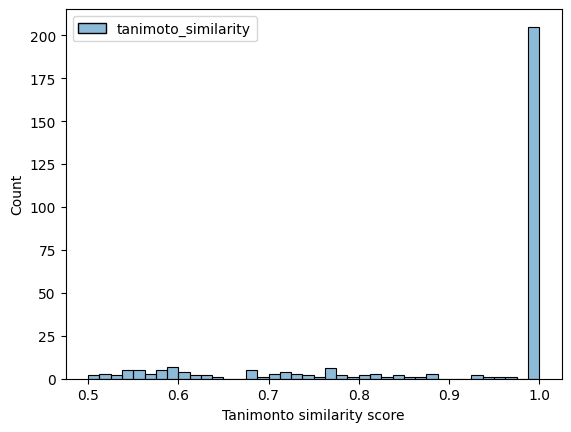

In [37]:
# Histogram of similarity scores
# The high peak at 1 indicates that we can clearly separate matches from non-matches
sns.histplot(similarity_results.groupby("query_name").max("tanimoto_similarity"),
             bins=40)
plt.xlabel("Tanimonto similarity score")

Overview of the tables and their identifying keys:
1. `modelId_to_inchi_mapping`
    * id: psamm model ID
    * name: psamm model name
2. `metabName_to_inchi_mapping`
    * metabolite_name: JGI internal name (or name from automatic annotation for untargeted)
    * query_name: Cleaned version of the JGI internal name, used to query pubchem
3. `similarity_results`
    * **The columns for this depend on which ones you chose when calling the main_structure_matching function**.
    Based on this structure: `query_name_col='metabolite_name', ref_name_col='name'` the columns would be the following:  
    * `query_name`: `metabolite_name` from `metabName_to_inchi_mapping`
    * `ref_name`: `name` from `modelId_to_inchi_mapping`
4. `pfu_targeted_limma`:
    * `metabolite`: JGI internal name.  
    Corresponds to `metabolite_name` from `metabName_to_inchi_mapping`
5. `pfu_untargeted_limma`:
    * `propagated_annotation`: Automatic name from untargeted annotation.
    Corresponds to `metabolite_name` from `metabName_to_inchi_mapping`
    

Mapping procedure:

0. Filter similarity_results to only include perfect matches
1. Merge similarity_results with modelId_to_inchi_mapping, mapping 'ref_name' to 'name'. Drop the inchi columns
2. Merge pfu_targeted_limma with table from 1, mapping 'metabolite' to 'query_name'
3. Merge pfu_untargeted_limma with table from 1, mapping 'propagated_annotation' to 'query_name'

In [38]:
perfect_matches = similarity_results.query("tanimoto_similarity > 0.999")

In [39]:
model_to_JGI_map = (modelId_to_inchi_mapping
    .merge(perfect_matches, left_on="name", right_on="ref_name")
    .drop(columns=["name", "inchi", "inchi_key", "neutral_inchi",
                   "neutral_inchi_key", "tanimoto_similarity"])
    .rename(columns={"query_name": "JGI_name", "ref_name": "model_name",
                     "id": "model_id"})
                    )

In [41]:
# Save the data to a tsv
model_to_JGI_map.drop_duplicates(["JGI_name"]).to_csv(
    os.path.join(outdir, "model_to_JGI_map.tsv"), sep="\t")

Next, I manually curated some of the IDs (particularly important for sugars). 
For some sugars, metabolomics won't be able to distinguish them (e.g. mannose vs glucose). I chose the version that we expect to see in the model (e.g. mannose in the metabolomics data maps to glucose in the model).

The edited version is saved in `model_to_JGI_map_edited.tsv`

### Read in the model mapping results

In [43]:
# After editing the table manually, reread it
model_to_JGI_map = pd.read_table(os.path.join(outdir, "model_to_JGI_map_edited.tsv"),
                                 sep="\t", index_col=0)

In [44]:
# Priority is used to weight higher quality annotations first
targ_annot = pfu_targeted_limma.merge(model_to_JGI_map, left_on="metabolite", right_on="JGI_name")
targ_annot["priority"] = 0

untarg_annot = pfu_untargeted_limma.merge(model_to_JGI_map, left_on="propagated_annotation", right_on="JGI_name")
untarg_annot["priority"] = 1
untarg_annot.loc[untarg_annot["annotation_source"] == "propagated", "priority"] = 2

In [45]:
# Merging targeted and untargeted annotations
limma_results = pd.concat([targ_annot, untarg_annot]).drop(columns=[
    "fullpath", "feature_id", "metabolite", "adduct", "row.m.z",
    "row.retention.time", "propagated_annotation"])

limma_results_dedupe = (limma_results
                        .sort_values(["priority", "adj.P.Val"])
                        .drop_duplicates("model_id", keep="first"))

In [47]:
limma_results_dedupe.to_csv(os.path.join(outdir, "limma_results_dedupe.tsv"), sep="\t")

### Plotting

In [49]:
pathway_classification = {
    'Glycolysis/Central Carbon': [
        'Phosphoenolpyruvate (PEP)',
        '3-Phospho-D-glycerate (3PG)',
        '2-Phospho-D-glycerate (2PG)',
        'Glyceraldehyde 3-phosphate (GAP)',
        'D-Glucose 6-phosphate (G6P)',
        'D-Fructose 6-phosphate (F6P)',
        'Pyruvate (Pyr)',
        'D-Glucose',
        'Acetyl-CoA (AcCoA)',
        'Isocitrate',
        'Fumarate',
        'L-Malate',
        'Acetoin'
    ],
    
    'Purine Metabolism': [
        'Guanine',
        'Hypoxanthine',
        'Adenine',
        'AMP',
        'Adenosine',
        'Inosine',
        'Guanosine',
        'ADP',
        'dAMP'
    ],
    
    'Pyrimidine Metabolism': [
        'Cytosine',
        'Uracil',
        'Cytidine',
        'Thymine',
        'Deoxycytidine',
        'Thymidine',
        'Uridine',
        'Orotate'
    ],
    
    'NAD/Nicotinamide': [
        'NADP',
        'NAD',
        'Nicotinamide'
    ],
    
    'Vitamins': [
        'Thiamine',
        'Riboflavin',
        'Biotin',
        'Pantothenate',
        'Pyridoxine'
    ],
    
    'Polyamines and SAM-related': [
        'L-2-Aminoadipate',
        'Putrescine',
        'Spermine',
        'Agmatine',
        'L-Citrulline (Clt)',
        'L-Lysine (lys-L)',
        'L-Proline (Pro-L)',
        'L-Arginine (Arg-L)',
        'L-Methionine (Met-L)',
        'L-Ornithine (Orn)',
        '5-Methylthioadenosine',
        'S-Adenosyl-L-methionine (SAM)'
    ],
    
    'Lipid Precursors': [
        '(R)-Mevalonate (MEV)',
        'myo-Inositol',
    ],
    
    'Branched-Chain Amino Acids': [
        'L-Isoleucine (Ile-L)',
        'L-Leucine (Leu-L)',
        '4-Methyl-2-oxopentanoate',
        'Citraconic acid'
    ],
    
    'Aromatic Amino Acids': [
        'L-Phenylalanine (Phe-L)',
        'L-Tyrosine (Tyr-L)',
        'L-Tryptophan (Trp-L)',
        'Anthranilate',
        'Indole-3-acetate',
    ],
    
    'Other Amino Acids': [
        'L-Aspartic acid (Asp-L)',
        'L-Histidine (His-L)',
        'L-Glutamine (Gln-L)',
        'L-Glutamic acid (Glu-L)',
        'L-Alanine (Ala-L)',
        'L-Homoserine',
        'L-Serine (Ser-L)',
        'L-Asparagine (Asn-L)',
        'L-Glycine (Gly-L)',
        'L-Threonine (Thr-L)',
    ],
    
    'Sugars & Carbohydrates': [
        'Mannitol',
        'Gentiobiose',
        'alpha,alpha-Trehalose',
        'Maltose',
        'Raffinose',
        'Cellobiose',
        'Sucrose',
        'D-Mannose',
        'D-Gluconate'
    ],
    
    'Amino Sugars & Cell Wall': [
        'N-Acetyl-D-glucosamine (GlcNAc)',
        'D-Glucosamine',
        'UDP-N-acetyl-D-glucosamine',
        'UDPglucose'
    ],
}

metabolite_to_pathway = {}
for pathway, metabolites in pathway_classification.items():
    for metabolite in metabolites:
        metabolite_to_pathway[metabolite] = pathway

limma_results_dedupe['pathway'] = limma_results_dedupe['model_name'].map(metabolite_to_pathway)

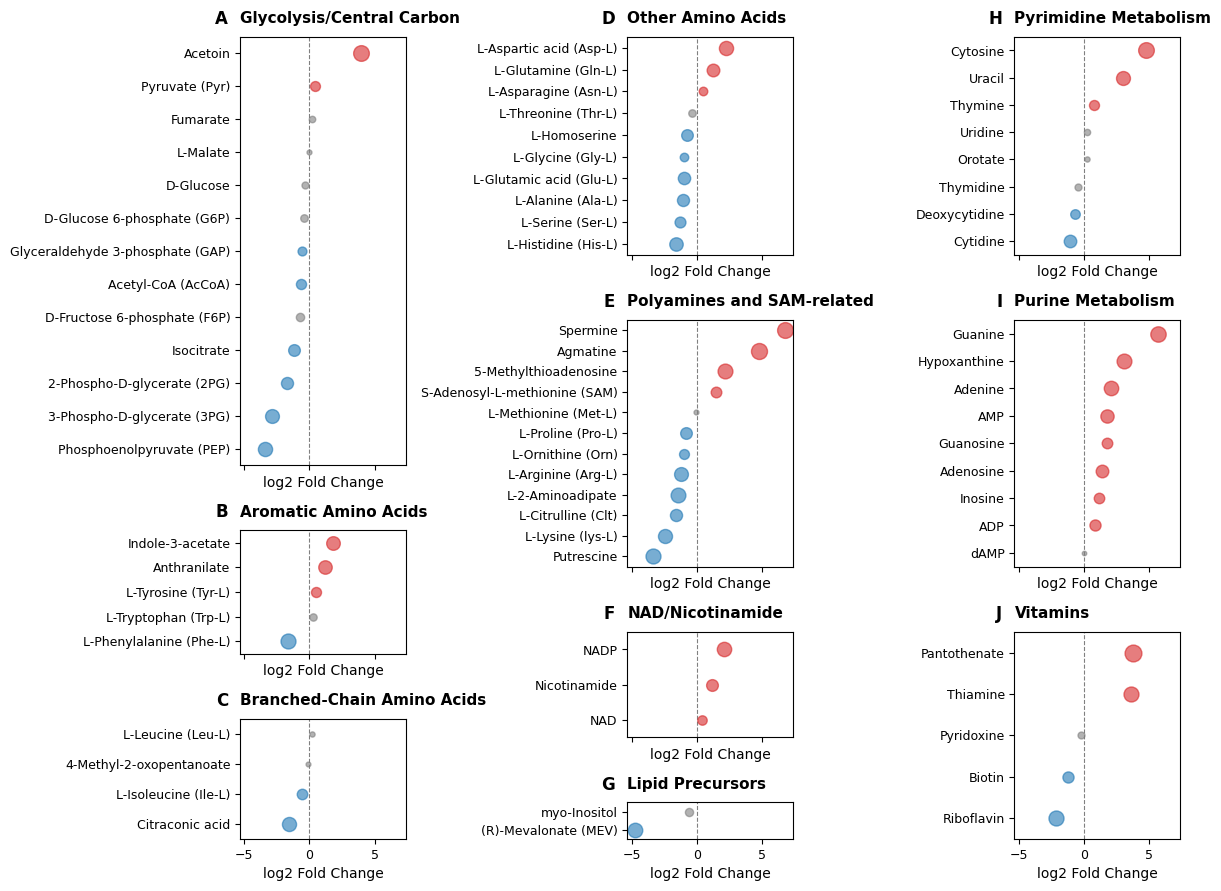

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pal = sns.color_palette("tab10")
color_map = {
    'Up': pal[3],
    'Down': pal[0],
    'NS': pal[7]
}

#pathways = limma_results_dedupe['pathway'].unique()
pathways_custom_order = ["Glycolysis/Central Carbon", "Aromatic Amino Acids", "Branched-Chain Amino Acids",
                         "Other Amino Acids", "Polyamines and SAM-related", "NAD/Nicotinamide",
                         "Lipid Precursors", "Pyrimidine Metabolism", "Purine Metabolism", "Vitamins"]

panel_configs = {chr(65+i): pathway for i, pathway in enumerate(pathways_custom_order)}

layout = [
    ['A', 'D', 'H'],
    ['A', 'E', 'I'],
    ['B', 'E', 'I'],
    ['B', 'F', 'J'],
    ['C', 'F', 'J'],
    ['C', 'G', 'J'],
]

width_ratios = [1, 1, 1]
height_ratios = [0.6, 0.4, 0.1, 0.06, 0.05, 0.1]
figsize = (12, 9)

fig, axs = plt.subplot_mosaic(layout, 
                              width_ratios=width_ratios,
                              height_ratios=height_ratios,
                              figsize=figsize,
                              sharex=True)

for panel_label, pathway in panel_configs.items():
    if panel_label not in axs:
        continue
    
    ax = axs[panel_label]
    
    plot_df = limma_results_dedupe[limma_results_dedupe['pathway'] == pathway].copy()
    plot_df['size'] = 10 + -np.log10(plot_df['adj.P.Val']) * 20
    plot_df = plot_df.sort_values("logFC")
    
    for _, row in plot_df.iterrows():
        ax.scatter(
            x=row['logFC'],
            y=row['model_name'],
            color=color_map[row['significance']],
            s=row['size'],
            alpha=0.6,
            label=row['significance']
        )
    
    n_reactions = len(plot_df['model_name'].unique())
    fixed_margin = 0.5  # Fixed margin in data units
    ax.set_ylim(-fixed_margin, n_reactions - 1 + fixed_margin)
    
    ax.axvline(0, color="grey", ls="--", zorder=0, linewidth=0.8)
    ax.set_xlabel('log2 Fold Change', fontsize=10)
    ax.set_ylabel('', fontsize=10)
    ax.set_title(pathway, fontsize=11, pad=10, fontweight='bold', loc='left')
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()

# Add panel labels
for panel_label, config in panel_configs.items():
    if panel_label not in axs:
        continue
    ax = axs[panel_label]

    bb = ax.get_position()  # returns Bbox with x0, y0, x1, y1 in figure fraction

    # Place label at top-left of axes, with a small offset
    x_fig = bb.x0 - 0.01
    y_fig = bb.y1 + 0.01

    fig.text(
        x_fig, y_fig,
        panel_label,
        fontsize=12,
        fontweight='bold',
        va='bottom',
        ha='right',
        transform=fig.transFigure
    )
    
plt.savefig(os.path.join(outdir, 'Fig_9_metabolome_changes.png'),
            dpi=300, bbox_inches='tight')
plt.show()

# Figure 7: Network plot

The code for producing Figure 7 (interactive network plot) can be found here: https://github.com/jvjvjvjv/pfu-bdo-networkvis

Docker image for running the visualization is available in dockerhub: jvjvjvjv/pfu-bdo-networkvis

# MRA companion paper figure

In [33]:
# Number of metabolites identified in the targeted dataset
len(set([x.replace("_unlabeled", "") for x in pfu_targeted_limma.metabolite]))

239

In [34]:
# Number of metabolites in the untargeted dataset
pfu_untargeted_limma.query("~propagated_annotation.isna() & annotation_source != 'propagated'").shape[0]

694

In [35]:
# Total number of features in the untargeted dataset
pfu_untargeted_limma.shape[0]

18666

In [37]:
pfu_untargeted_limma

,feature_id,logFC,AveExpr,t,P.Value,adj.P.Val,B,metabolite,chemistry,mode,variable,row.m.z,row.retention.time,propagated_annotation,annotation_source,significance
1,0,0.089808,18.616757,0.574462,5.818834e-01,0.776760,-7.248724,605,C18,POS,peak_height,81.520557,0.254904,NaN,NaN,NS
2,1,-0.023562,23.846305,-0.153741,8.817278e-01,0.949959,-7.417186,800,HILIC,NEG,peak_height,641.090550,0.838742,NaN,NaN,NS
3,10,0.147143,20.216674,0.231878,8.226167e-01,0.923560,-7.400326,1543,HILIC,NEG,peak_height,289.057265,0.809672,NaN,NaN,NS
4,100,-0.156098,16.357984,-0.247061,8.112566e-01,0.918438,-7.396267,2215,HILIC,POS,peak_height,506.381960,0.819431,NaN,NaN,NS
5,10004,3.007619,19.595087,14.787939,5.682129e-07,0.000017,6.960470,17406,HILIC,NEG,peak_height,319.134473,5.431820,NaN,NaN,Up
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18662,9984,-0.040629,14.299597,-0.352637,7.337246e-01,0.876076,-7.361083,17379,C18,POS,peak_height,452.530836,2.658712,NaN,NaN,NS
18663,9987,-0.891894,16.670425,-2.621195,3.133402e-02,0.091688,-4.665329,17386,HILIC,NEG,peak_height,228.032321,5.445362,NaN,NaN,NS
18664,999,0.320300,20.328458,2.301885,5.121915e-02,0.136132,-5.160520,5215,C18,NEG,peak_height,305.064350,0.834481,NaN,NaN,NS
18665,9994,-0.936441,16.624951,-3.032765,1.678635e-02,0.055585,-4.022753,17391,C18,POS,peak_height,418.549770,2.657731,NaN,NaN,NS


In [36]:
pfu_targeted_limma

,feature_id,logFC,AveExpr,t,P.Value,adj.P.Val,B,metabolite,adduct,fullpath,chemistry,mode,database,CustomStds,variable,significance
0,1002,-1.000400,15.928895,-2.416372,3.976321e-02,0.063413,-5.214643,antioxidant_2246,M-e,/work/pi_yingzhang_uri_edu/jvailionis/metabolo...,C18,POS,EMA,False,peak_height,NS
1,1008,-1.207382,20.465664,-9.573275,6.602186e-06,0.000042,4.052137,arabinitol_U13C,M-H,/work/pi_yingzhang_uri_edu/jvailionis/metabolo...,HILIC,NEG,ISTD,False,peak_height,Down
2,1014,1.220686,19.939697,5.766396,3.090246e-04,0.000951,-0.109114,arabinitol_unlabeled,M-H,/work/pi_yingzhang_uri_edu/jvailionis/metabolo...,HILIC,NEG,ISTD,False,peak_height,Up
3,1026,-0.992166,27.898145,-7.842805,3.168908e-05,0.000152,2.354881,arginine,M+H,/work/pi_yingzhang_uri_edu/jvailionis/metabolo...,HILIC,POS,EMA,False,peak_height,Down
4,1032,-1.219954,24.467603,-9.914291,4.984875e-06,0.000034,4.355527,arginine,M-H,/work/pi_yingzhang_uri_edu/jvailionis/metabolo...,HILIC,NEG,EMA,False,peak_height,Down
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,936,-0.633942,28.129984,-4.829752,1.032291e-03,0.002708,-1.406228,alanine_unlabeled,M+H,/work/pi_yingzhang_uri_edu/jvailionis/metabolo...,HILIC,POS,ISTD,False,peak_height,Down
377,966,-1.478993,21.997347,-10.717564,2.653593e-06,0.000023,5.035111,alpha-aminoadipic_acid,M+H,/work/pi_yingzhang_uri_edu/jvailionis/metabolo...,HILIC,POS,EMA,False,peak_height,Down
378,972,-1.455400,20.762979,-13.154579,4.915802e-07,0.000007,6.841132,alpha-aminoadipic_acid,M-H,/work/pi_yingzhang_uri_edu/jvailionis/metabolo...,HILIC,NEG,EMA,False,peak_height,Down
379,99,1.039888,19.666589,6.612393,1.149985e-04,0.000419,0.959112,3-methyloxindole,M+H,/work/pi_yingzhang_uri_edu/jvailionis/metabolo...,C18,POS,EMA,False,peak_height,Up
